# PM2.5 Forecasting — Transformer Model

**Project:** DSA SCI 8001 Time Series Analysis — Final Project  
**Input:** `la_daily_2017_2023_clean.csv`  
**Task:** Multi-step ahead forecasting of daily PM2.5 (horizon = 1–7 days)  
**Architecture:** Encoder-only Transformer with positional encoding (PyTorch)

---

## Model Design Overview

We implement a **multivariate encoder-only Transformer** for time series forecasting:

- **Input features:** `pm25_cf_1`, `humidity`, `temperature`, `day_of_week` (sin/cos), `month` (sin/cos)
- **Target:** `pm25_cf_1` only
- **Look-back window:** 14 days
- **Forecast horizon:** 7 days
- **Architecture:** Linear input projection → Positional Encoding → Transformer Encoder layers → Linear output head

**Why encoder-only?**  
For forecasting with a fixed horizon, an encoder-only architecture that maps a past window to future predictions is simpler, faster to train, and less prone to overfitting than a full encoder-decoder setup — appropriate given our dataset size (~1400 training days).

---

## Data Split

| Split | Period | Days |
|-------|--------|------|
| Train | 2017-01-01 – 2020-12-31 | 1461 |
| Validation | 2021-01-01 – 2021-12-31 | 365 |
| Test | 2022-01-01 – 2022-12-31 | 365 |

## 0. Imports & Config

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import math
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── Config ─────────────────────────────────────────────────────────────────
DATA_PATH    = "../data/la_daily_2017_2023_clean.csv"
OUTPUT_DIR   = "../figures/"


LOOKBACK     = 14    # days of history fed to the model
HORIZON      = 7     # days ahead to forecast
BATCH_SIZE   = 32
EPOCHS       = 200
LR           = 5e-4
D_MODEL      = 32    # Transformer embedding dimension
N_HEADS      = 4     # attention heads (D_MODEL must be divisible by N_HEADS)
N_LAYERS     = 1     # Transformer encoder layers
DROPOUT      = 0.2
SEED         = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


---
## 1. Data Loading & Feature Engineering

We add **cyclic time features** (sine/cosine encodings of day-of-week and month) to provide the model with explicit calendar context. Cyclic encoding is preferred over integer encoding because it preserves the continuity of time — e.g. day 7 and day 1 should be "close" in feature space, which integer encoding does not capture.

In [2]:
df = pd.read_csv(DATA_PATH, index_col="date", parse_dates=True)

# Cyclic encoding for day-of-week (0–6) and month (1–12)
df["dow_sin"] = np.sin(2 * np.pi * df.index.dayofweek / 7)
df["dow_cos"] = np.cos(2 * np.pi * df.index.dayofweek / 7)
df["month_sin"] = np.sin(2 * np.pi * (df.index.month - 1) / 12)
df["month_cos"] = np.cos(2 * np.pi * (df.index.month - 1) / 12)

FEATURE_COLS = ["pm25_cf_1", "humidity", "temperature", "dow_sin", "dow_cos", "month_sin", "month_cos"]
TARGET_COL   = "pm25_cf_1"
TARGET_IDX   = FEATURE_COLS.index(TARGET_COL)  # index 0

# Train / Val / Test split
train_df = df[df.index < "2021-01-01"]
val_df   = df[(df.index >= "2021-01-01") & (df.index < "2022-01-01")]
test_df  = df[(df.index >= "2022-01-01") & (df.index < "2023-01-01")]

print(f"Train: {len(train_df)} days | Val: {len(val_df)} days | Test: {len(test_df)} days")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

Train: 1461 days | Val: 365 days | Test: 365 days
Features (7): ['pm25_cf_1', 'humidity', 'temperature', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']


---
## 2. Normalization

All features are standardized (zero mean, unit variance) using `StandardScaler` fitted **only on the training set** to prevent data leakage into validation and test sets.

In [3]:
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[FEATURE_COLS])
val_scaled   = scaler.transform(val_df[FEATURE_COLS])
test_scaled  = scaler.transform(test_df[FEATURE_COLS])

# We also need a scaler for the target only (for inverse-transforming predictions)
target_scaler = StandardScaler()
target_scaler.fit(train_df[[TARGET_COL]])

print("Normalization complete. Train mean/std (pm25):")
print(f"  mean = {target_scaler.mean_[0]:.3f}, std = {target_scaler.scale_[0]:.3f}")

Normalization complete. Train mean/std (pm25):
  mean = 14.672, std = 11.024


---
## 3. Dataset & DataLoader

We use a **sliding window** approach: each sample consists of a `LOOKBACK`-day input window and a `HORIZON`-day target sequence. The window slides one day at a time across the time series.

In [4]:
class PM25Dataset(Dataset):
    """
    Sliding-window dataset for time series forecasting.

    Each sample:
      X : (LOOKBACK, n_features)  — past window of all features
      y : (HORIZON,)              — future PM2.5 values to predict
    """
    def __init__(self, data: np.ndarray, lookback: int, horizon: int, target_idx: int):
        self.data       = data
        self.lookback   = lookback
        self.horizon    = horizon
        self.target_idx = target_idx

    def __len__(self):
        return len(self.data) - self.lookback - self.horizon + 1

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.lookback]                          # (lookback, features)
        y = self.data[idx + self.lookback : idx + self.lookback + self.horizon, self.target_idx]  # (horizon,)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


train_dataset = PM25Dataset(train_scaled, LOOKBACK, HORIZON, TARGET_IDX)
val_dataset   = PM25Dataset(val_scaled,   LOOKBACK, HORIZON, TARGET_IDX)
test_dataset  = PM25Dataset(test_scaled,  LOOKBACK, HORIZON, TARGET_IDX)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
# Verify shapes
xb, yb = next(iter(train_loader))
print(f"Batch shapes — X: {xb.shape}, y: {yb.shape}")

Train samples: 1441 | Val: 345 | Test: 345
Batch shapes — X: torch.Size([32, 14, 7]), y: torch.Size([32, 7])


---
## 4. Model Architecture

### Positional Encoding
Since Transformer self-attention is permutation-invariant, we inject **sinusoidal positional encodings** to provide the model with information about the relative order of timesteps in the input window.

### Encoder-only Transformer
```
Input (14 × 7)
    ↓  Linear projection
(14 × D_MODEL=32)
    ↓  Positional Encoding
(14 × 32)
    ↓  TransformerEncoder (N_LAYERS=1, N_HEADS=4)
(14 × 32)
    ↓  Flatten last timestep
(32,)
    ↓  Linear output head
(HORIZON=7,)
```

In [5]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding as in Vaswani et al. (2017)."""
    def __init__(self, d_model: int, max_len: int = 512, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)          # (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x):             # x: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class TransformerForecaster(nn.Module):
    """
    Encoder-only Transformer for multi-step time series forecasting.

    Parameters
    ----------
    n_features : int  — number of input features per timestep
    d_model    : int  — internal embedding dimension
    n_heads    : int  — number of self-attention heads
    n_layers   : int  — number of Transformer encoder layers
    horizon    : int  — number of future timesteps to predict
    dropout    : float
    """
    def __init__(self, n_features, d_model, n_heads, n_layers, horizon, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_enc    = PositionalEncoding(d_model, dropout=dropout)

        encoder_layer   = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True
        )
        self.encoder    = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.output_head = nn.Linear(d_model, horizon)

    def forward(self, x):             # x: (batch, lookback, n_features)
        x = self.input_proj(x)        # → (batch, lookback, d_model)
        x = self.pos_enc(x)
        x = self.encoder(x)           # → (batch, lookback, d_model)
        x = x[:, -1, :]               # take last timestep: (batch, d_model)
        return self.output_head(x)    # → (batch, horizon)


N_FEATURES = len(FEATURE_COLS)
model = TransformerForecaster(
    n_features=N_FEATURES,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    horizon=HORIZON,
    dropout=DROPOUT
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {total_params:,}")

TransformerForecaster(
  (input_proj): Linear(in_features=7, out_features=32, bias=True)
  (pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=128, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=128, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (output_head): Linear(in_features=32, out_features=7, bias=True)
)

Trainable parameters: 13,191


---
## 5. Training

We use **MSE loss** and the **Adam optimizer** with a `ReduceLROnPlateau` scheduler that halves the learning rate when validation loss stagnates for 10 epochs. **Early stopping** (patience = 40 epochs) prevents overfitting and saves the best checkpoint.

In [6]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=10
)

PATIENCE    = 40
best_val_loss = float("inf")
patience_counter = 0
train_losses, val_losses = [], []
CKPT_PATH = "../best_model/transformer_best.pt"

for epoch in range(1, EPOCHS + 1):

    # ── Training ────────────────────────────────────────────────────────────
    model.train()
    epoch_train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()
        epoch_train_loss += loss.item()
    epoch_train_loss /= len(train_loader)

    # ── Validation ──────────────────────────────────────────────────────────
    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred = model(xb)
            epoch_val_loss += criterion(pred, yb).item()
    epoch_val_loss /= len(val_loader)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    scheduler.step(epoch_val_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

    # ── Early stopping ───────────────────────────────────────────────────────
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), CKPT_PATH)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch} (best val loss: {best_val_loss:.4f})")
            break

print(f"\nBest validation loss: {best_val_loss:.4f}")

Epoch  10 | Train Loss: 0.8013 | Val Loss: 0.4910
Epoch  20 | Train Loss: 0.7739 | Val Loss: 0.4941
Epoch  30 | Train Loss: 0.7608 | Val Loss: 0.5073
Epoch  40 | Train Loss: 0.7543 | Val Loss: 0.5097
Early stopping at epoch 49 (best val loss: 0.4867)

Best validation loss: 0.4867


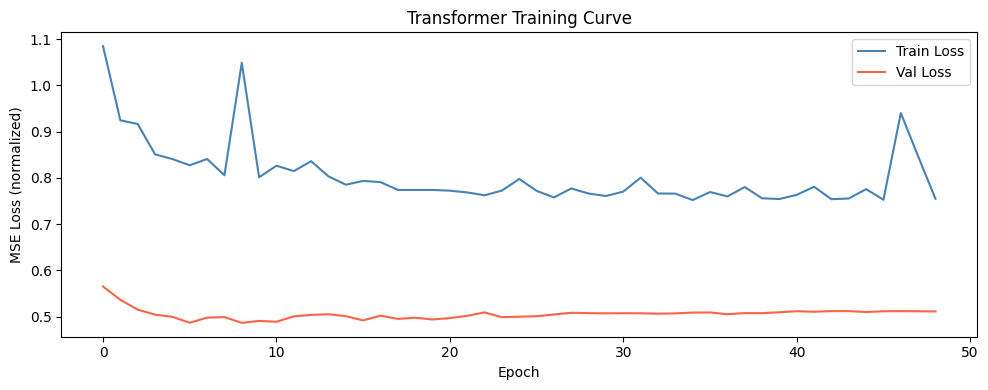

In [7]:
# Training curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label="Train Loss", color="steelblue")
ax.plot(val_losses,   label="Val Loss",   color="tomato")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss (normalized)")
ax.set_title("Transformer Training Curve")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig_transformer_training_curve.png", dpi=150)
plt.show()

---
## 6. Evaluation on Test Set (2022)

We load the best checkpoint and evaluate across all 7 forecast horizons using three metrics:
- **MAE** (Mean Absolute Error) — average absolute error in µg/m³
- **RMSE** (Root Mean Squared Error) — penalises large errors more heavily
- **MAPE** (Mean Absolute Percentage Error) — scale-independent, interpretable as %

In [8]:
# Load best model
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

all_preds, all_targets = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        pred = model(xb).cpu().numpy()   # (batch, horizon) — normalized
        all_preds.append(pred)
        all_targets.append(yb.numpy())

preds   = np.concatenate(all_preds,   axis=0)   # (N, horizon)
targets = np.concatenate(all_targets, axis=0)   # (N, horizon)

# Inverse-transform to original PM2.5 scale (µg/m³)
preds_inv   = target_scaler.inverse_transform(preds)
targets_inv = target_scaler.inverse_transform(targets)

# Metrics per horizon step
print(f"{'Horizon':<10} {'MAE':>8} {'RMSE':>8} {'MAPE':>8}")
print("-" * 36)
maes, rmses, mapes = [], [], []
for h in range(HORIZON):
    y_true = targets_inv[:, h]
    y_pred = preds_inv[:, h]
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    maes.append(mae); rmses.append(rmse); mapes.append(mape)
    print(f"  t+{h+1:<7} {mae:>8.3f} {rmse:>8.3f} {mape:>7.1f}%")

print("-" * 36)
print(f"  {'Mean':<8} {np.mean(maes):>8.3f} {np.mean(rmses):>8.3f} {np.mean(mapes):>7.1f}%")

Horizon         MAE     RMSE     MAPE
------------------------------------
  t+1          3.467    4.508    49.3%
  t+2          4.776    5.832    74.3%
  t+3          5.062    6.123    78.9%
  t+4          5.181    6.267    81.0%
  t+5          5.446    6.525    85.2%
  t+6          5.649    6.668    89.1%
  t+7          5.729    6.702    90.2%
------------------------------------
  Mean        5.044    6.089    78.3%


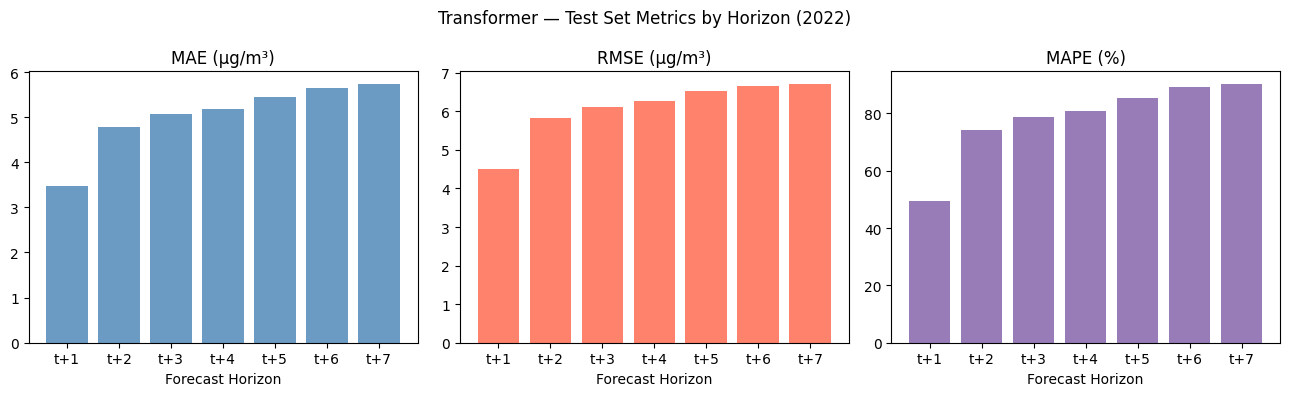

In [9]:
# Metrics across horizons plot
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
horizons = [f"t+{h+1}" for h in range(HORIZON)]

for ax, vals, label, color in zip(
    axes,
    [maes, rmses, mapes],
    ["MAE (µg/m³)", "RMSE (µg/m³)", "MAPE (%)"],
    ["steelblue", "tomato", "#7d5ba6"]
):
    ax.bar(horizons, vals, color=color, alpha=0.8)
    ax.set_title(label)
    ax.set_xlabel("Forecast Horizon")

fig.suptitle("Transformer — Test Set Metrics by Horizon (2022)", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig_transformer_metrics_by_horizon.png", dpi=150)
plt.show()

---
## 7. Forecast Visualization

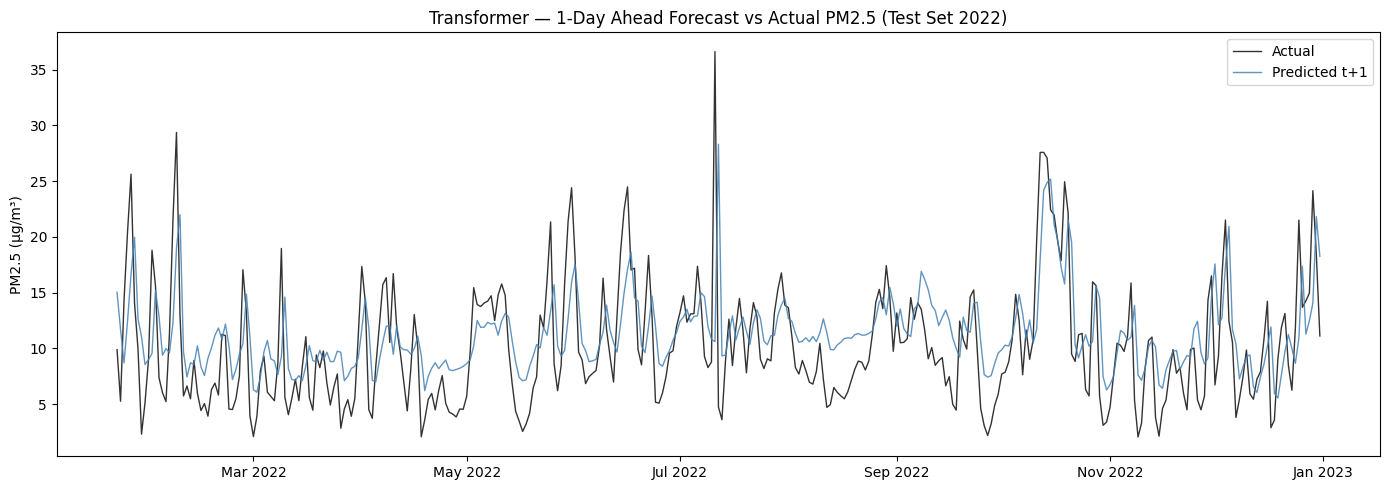

In [10]:
# Plot t+1 predictions vs actual for the full test year
# Align dates with actual prediction output length
n_preds = len(targets_inv)
test_dates = test_df.index[len(test_df) - n_preds:]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_dates, targets_inv[:, 0], label="Actual", color="#333333", lw=1.0)
ax.plot(test_dates, preds_inv[:, 0], label="Predicted t+1", color="steelblue", lw=1.0, alpha=0.85)
ax.set_title("Transformer — 1-Day Ahead Forecast vs Actual PM2.5 (Test Set 2022)")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig_transformer_forecast_t1.png", dpi=150)
plt.show()


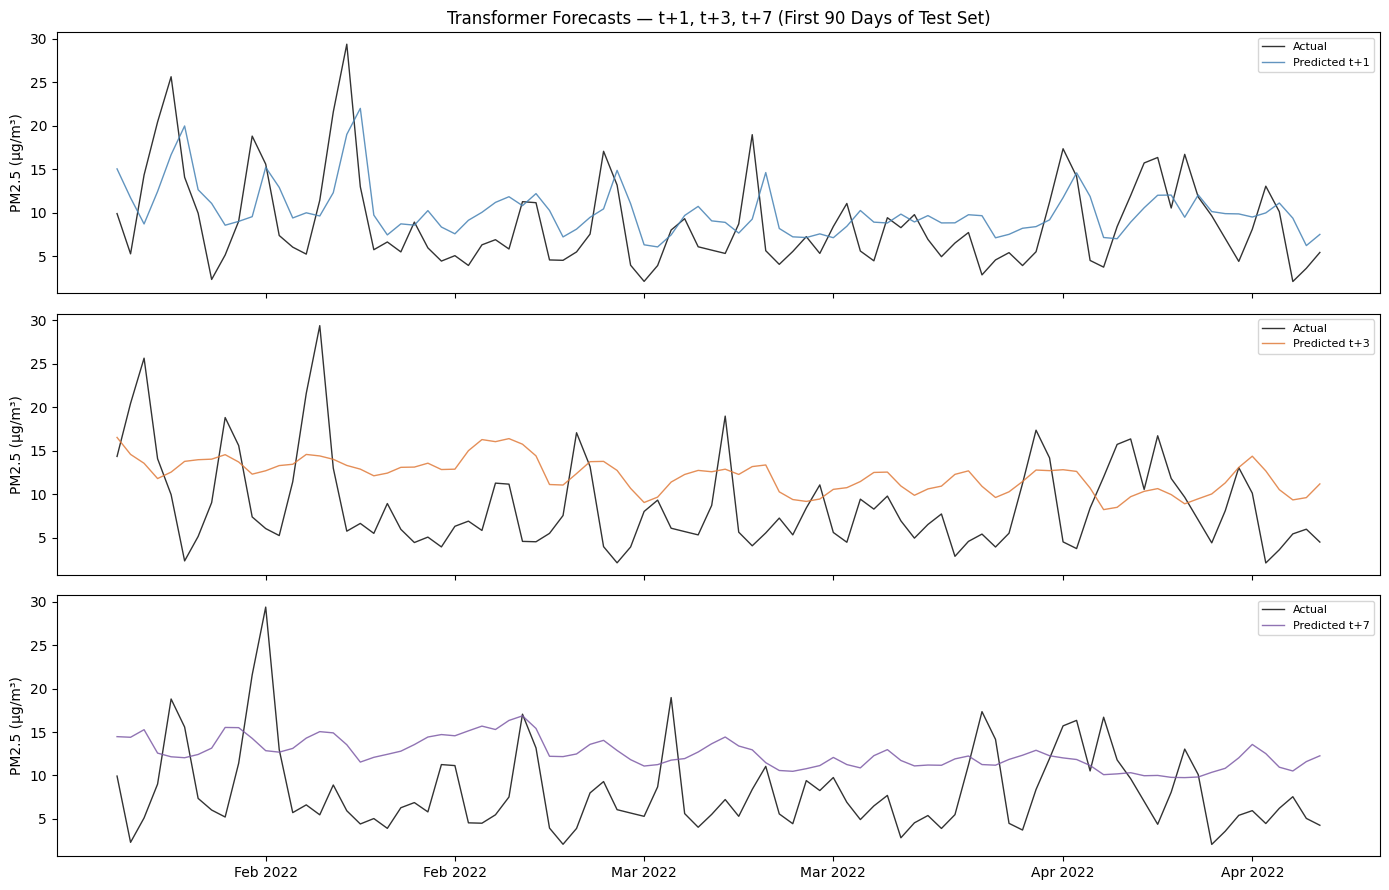

In [11]:
# Plot t+1, t+3, t+7 side by side for a 90-day window
WINDOW = 90
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

for ax, h, color in zip(axes, [0, 2, 6], ["steelblue", "#e07b3b", "#7d5ba6"]):
    ax.plot(test_dates[:WINDOW], targets_inv[:WINDOW, h],
            label="Actual", color="#333333", lw=1.0)
    ax.plot(test_dates[:WINDOW], preds_inv[:WINDOW, h],
            label=f"Predicted t+{h+1}", color=color, lw=1.0, alpha=0.85)
    ax.set_ylabel("PM2.5 (µg/m³)")
    ax.legend(loc="upper right", fontsize=8)

axes[0].set_title("Transformer Forecasts — t+1, t+3, t+7 (First 90 Days of Test Set)")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig_transformer_forecast_multihorizon.png", dpi=150)
plt.show()

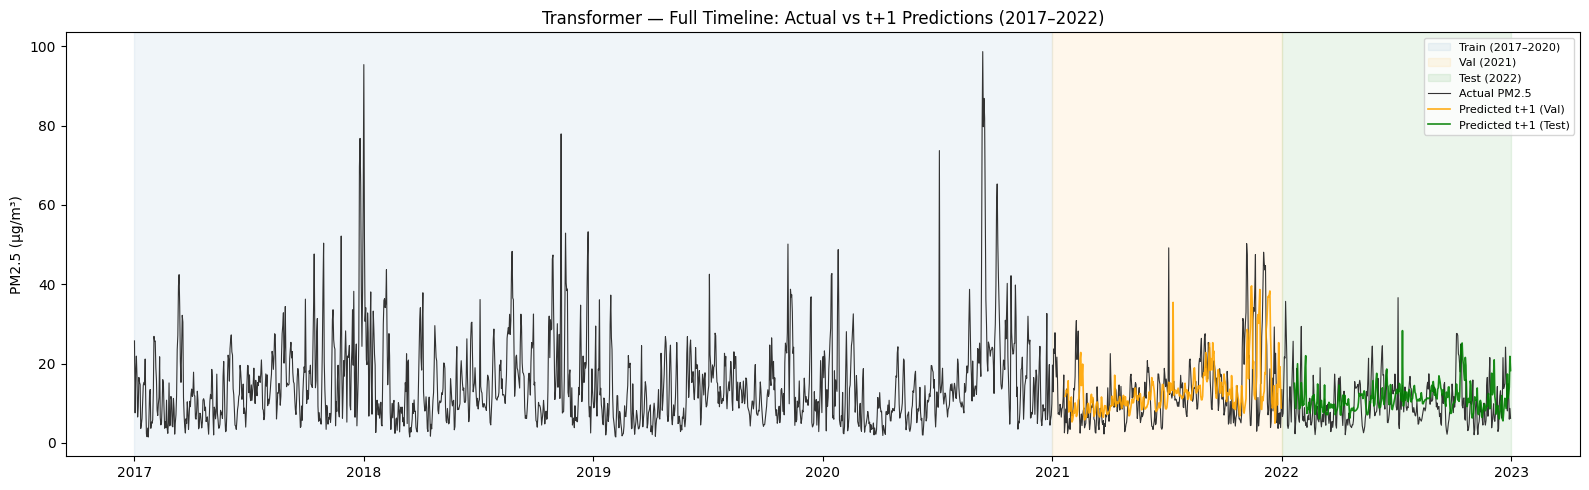

In [12]:
# ── Full timeline plot: Actual (all years) + Predictions (val & test) ───────

# --- Reconstruct val predictions ---
model.eval()
val_preds_list, val_targets_list = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(DEVICE)
        pred = model(xb).cpu().numpy()
        val_preds_list.append(pred)
        val_targets_list.append(yb.numpy())

val_preds_inv   = target_scaler.inverse_transform(np.concatenate(val_preds_list, axis=0))
val_targets_inv = target_scaler.inverse_transform(np.concatenate(val_targets_list, axis=0))

# --- Align dates ---
n_val  = len(val_preds_inv)
n_test = len(preds_inv)
val_dates  = val_df.index[len(val_df)  - n_val:]
test_dates2 = test_df.index[len(test_df) - n_test:]

# --- Full actual series ---
full_actual = df[df.index < "2023-01-01"]

fig, ax = plt.subplots(figsize=(16, 5))

# Background shading for each split
ax.axvspan(full_actual.index[0],  pd.Timestamp("2021-01-01"), alpha=0.08, color="steelblue",  label="Train (2017–2020)")
ax.axvspan(pd.Timestamp("2021-01-01"), pd.Timestamp("2022-01-01"), alpha=0.08, color="orange", label="Val (2021)")
ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2023-01-01"), alpha=0.08, color="green",  label="Test (2022)")

# Actual PM2.5 full series
ax.plot(full_actual.index, full_actual["pm25_cf_1"],
        color="#333333", lw=0.8, label="Actual PM2.5", zorder=2)

# Val t+1 prediction
ax.plot(val_dates, val_preds_inv[:, 0],
        color="orange", lw=1.2, alpha=0.9, label="Predicted t+1 (Val)", zorder=3)

# Test t+1 prediction
ax.plot(test_dates2, preds_inv[:, 0],
        color="green", lw=1.2, alpha=0.9, label="Predicted t+1 (Test)", zorder=3)

ax.set_title("Transformer — Full Timeline: Actual vs t+1 Predictions (2017–2022)", fontsize=12)
ax.set_ylabel("PM2.5 (µg/m³)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig_transformer_full_timeline.png", dpi=150)
plt.show()

---
## 8. Residual Analysis

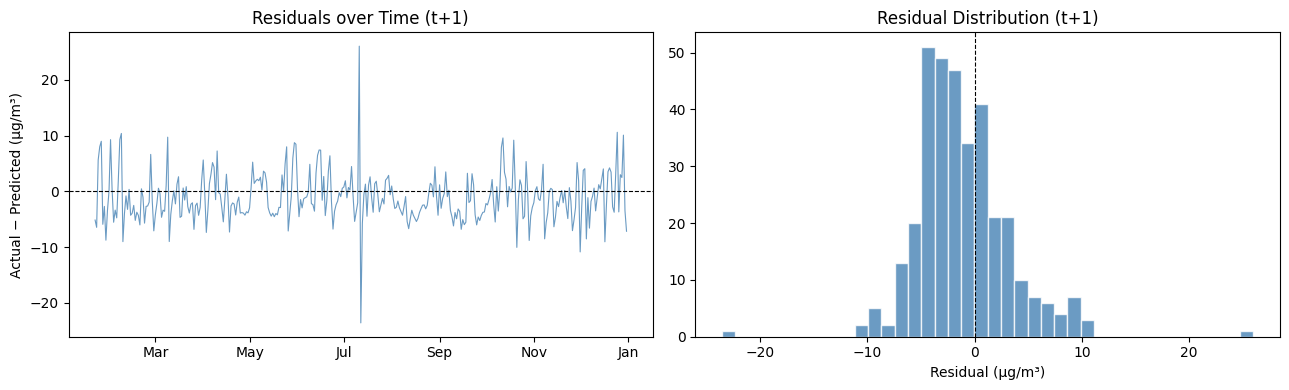

Residual mean: -1.122 µg/m³  (close to 0 = no systematic bias)
Residual std:  4.366 µg/m³


In [13]:
# Residuals for t+1
residuals = targets_inv[:, 0] - preds_inv[:, 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(test_dates, residuals, color="steelblue", lw=0.8, alpha=0.8)
axes[0].axhline(0, color="black", lw=0.8, ls="--")
axes[0].set_title("Residuals over Time (t+1)")
axes[0].set_ylabel("Actual − Predicted (µg/m³)")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b"))

axes[1].hist(residuals, bins=40, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].axvline(0, color="black", lw=0.8, ls="--")
axes[1].set_title("Residual Distribution (t+1)")
axes[1].set_xlabel("Residual (µg/m³)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig_transformer_residuals.png", dpi=150)
plt.show()

print(f"Residual mean: {residuals.mean():.3f} µg/m³  (close to 0 = no systematic bias)")
print(f"Residual std:  {residuals.std():.3f} µg/m³")

---
## 9. Save Results

In [14]:
# Save predictions to CSV for comparison with SARIMAX
results = pd.DataFrame(
    {f"actual_t+{h+1}": targets_inv[:, h] for h in range(HORIZON)}
    | {f"pred_t+{h+1}": preds_inv[:, h]   for h in range(HORIZON)},
    index=test_dates
)
results.index.name = "date"
results.to_csv("../model_predict/transformer_test_predictions.csv")
print("Saved: transformer_test_predictions.csv")

# Save summary metrics
metrics_df = pd.DataFrame({
    "horizon": [f"t+{h+1}" for h in range(HORIZON)],
    "MAE":  maes,
    "RMSE": rmses,
    "MAPE": mapes
})
metrics_df.to_csv("../model_predict/transformer_metrics.csv", index=False)
print("Saved: transformer_metrics.csv")

Saved: transformer_test_predictions.csv
Saved: transformer_metrics.csv


---
## Summary

| Component | Choice | Rationale |
|-----------|--------|-----------|
| Architecture | Encoder-only Transformer | Fixed-horizon forecasting does not require autoregressive decoding; simpler and less prone to overfitting on small datasets |
| Input | 7 features (pm25 + humidity + temp + 4 cyclic time features) | Meteorological variables improve forecast accuracy; cyclic encoding preserves calendar continuity |
| Look-back window | 14 days | Captures monthly seasonal patterns while keeping sequence length manageable |
| Positional encoding | Sinusoidal (Vaswani et al. 2017) | Standard choice for fixed-length windows; no additional learnable parameters |
| Loss | MSE | Standard for regression; penalises large errors which matter for air quality alerts |
| Regularisation | Dropout (0.1) + gradient clipping + early stopping | Prevents overfitting given ~1400 training days |

Predictions saved to `transformer_test_predictions.csv` for direct comparison with SARIMAX results.

---
## 10. Model Comparison: Transformer vs SARIMAX vs ARIMA

We compare all three models on the 2022 test set using MAE, RMSE, and MAPE. The Transformer is evaluated at the t+1 horizon for a fair comparison against the 1-step SARIMAX and ARIMA forecasts.

=== Model Comparison — Test Set 2022 ===
                  Model   MAE  RMSE  MAPE (%)
      Transformer (t+1) 3.467 4.508      49.3
SARIMAX(1,0,1)(1,0,1,7) 5.337 6.538      83.9
  ARIMA(1,0,1) baseline 5.896 6.872      97.1


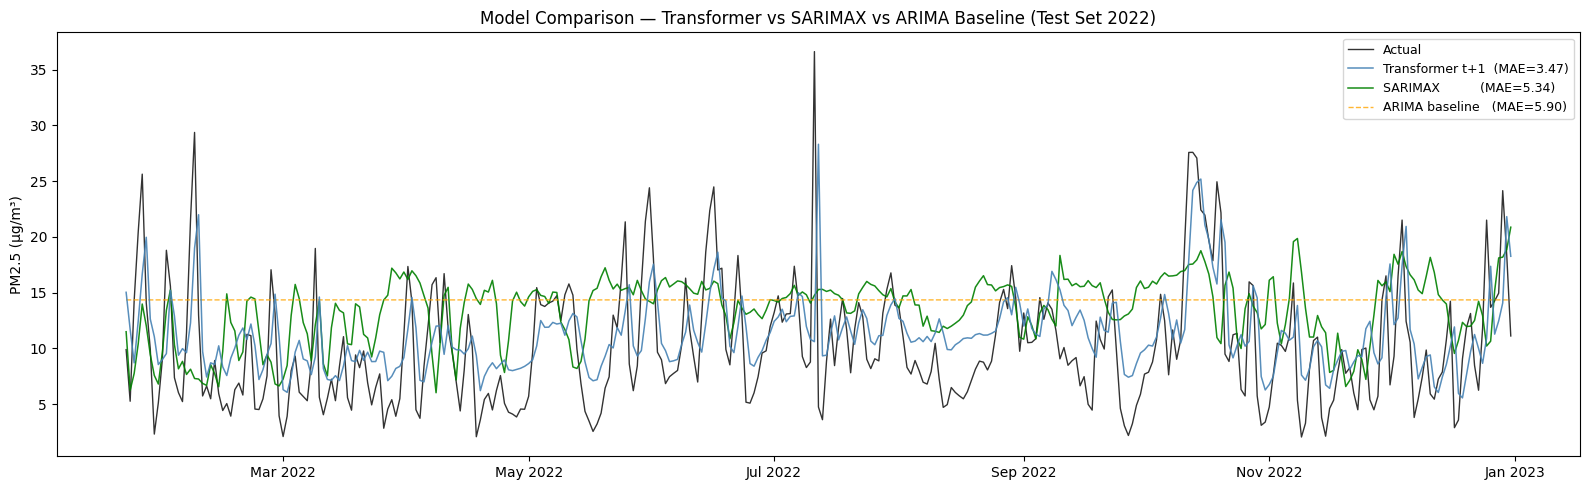

In [15]:
def get_metrics(actual, pred, name):
    mae  = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = np.mean(np.abs((actual - pred) / (actual + 1e-8))) * 100
    return {"Model": name, "MAE": round(mae,3), "RMSE": round(rmse,3), "MAPE (%)": round(mape,1)}

# predictions
transformer_df = pd.read_csv("../model_predict/transformer_test_predictions.csv",
                              index_col="date", parse_dates=True)
sarimax_df     = pd.read_csv("../model_predict/sarimax_test_predictions.csv",
                              index_col="date", parse_dates=True)
arima_df       = pd.read_csv("../model_predict/arima_test_predictions.csv",
                              index_col="date", parse_dates=True)

# Align on common dates
common_idx = transformer_df.index.intersection(sarimax_df.index).intersection(arima_df.index)
t_actual   = transformer_df.loc[common_idx, "actual_t+1"].values
t_pred     = transformer_df.loc[common_idx, "pred_t+1"].values
s_pred     = sarimax_df.loc[common_idx,    "predicted"].values
a_pred     = arima_df.loc[common_idx,      "predicted"].values

# Metrics table
metrics_df = pd.DataFrame([
    get_metrics(t_actual, t_pred, "Transformer (t+1)"),
    get_metrics(t_actual, s_pred, "SARIMAX(1,0,1)(1,0,1,7)"),
    get_metrics(t_actual, a_pred, "ARIMA(1,0,1) baseline"),
])
print("=== Model Comparison — Test Set 2022 ===")
print(metrics_df.to_string(index=False))
metrics_df.to_csv("../model_predict/model_comparison_metrics.csv", index=False)

# ── Single comparison plot: all 4 lines ─────────────────────
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(common_idx, t_actual, color="#333333",   lw=1.0, label="Actual",                                          zorder=2)
ax.plot(common_idx, t_pred,   color="steelblue", lw=1.1, alpha=0.9, label=f"Transformer t+1  (MAE={metrics_df.iloc[0]['MAE']:.2f})", zorder=4)
ax.plot(common_idx, s_pred,   color="green",     lw=1.1, alpha=0.9, label=f"SARIMAX          (MAE={metrics_df.iloc[1]['MAE']:.2f})", zorder=3)
ax.plot(common_idx, a_pred,   color="orange",    lw=1.0, alpha=0.8, label=f"ARIMA baseline   (MAE={metrics_df.iloc[2]['MAE']:.2f})", zorder=3, ls="--")

ax.set_title("Model Comparison — Transformer vs SARIMAX vs ARIMA Baseline (Test Set 2022)", fontsize=12)
ax.set_ylabel("PM2.5 (µg/m³)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig_model_comparison.png", dpi=150)
plt.show()

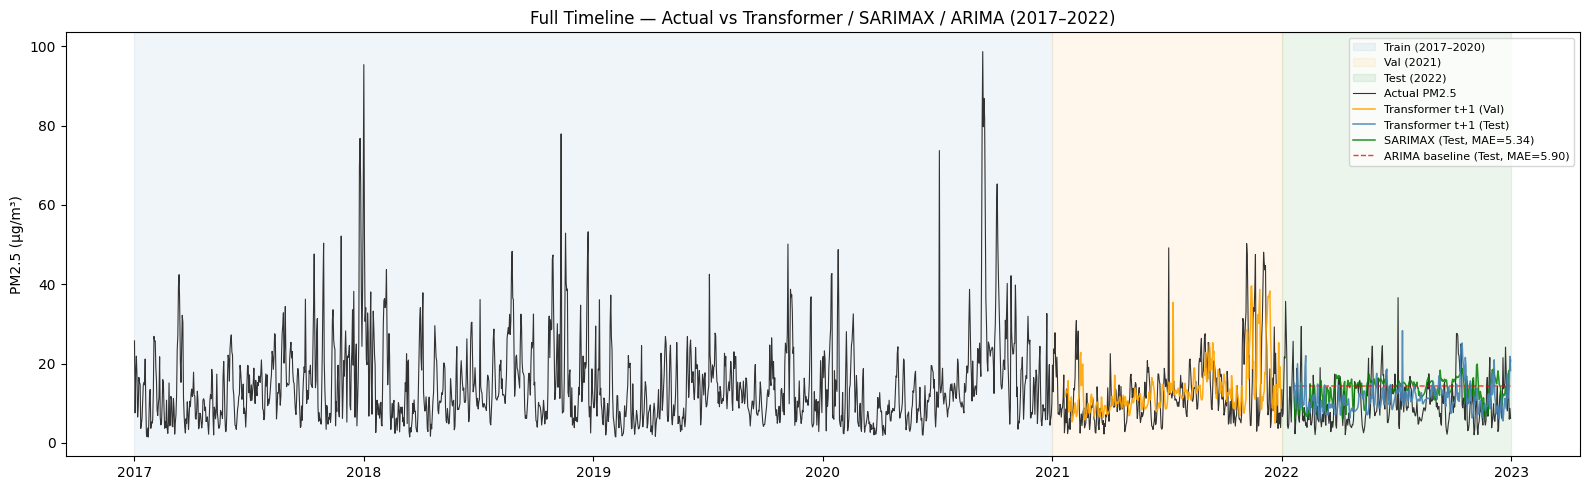

In [16]:
# ── Full timeline plot: all 3 models ────────────────────────
full_actual = df[df.index < "2023-01-01"]

# Align SARIMAX and ARIMA to common_idx
s_dates = sarimax_df.loc[common_idx].index
a_dates = arima_df.loc[common_idx].index

fig, ax = plt.subplots(figsize=(16, 5))

# Background shading
ax.axvspan(full_actual.index[0],       pd.Timestamp("2021-01-01"), alpha=0.08, color="steelblue", label="Train (2017–2020)")
ax.axvspan(pd.Timestamp("2021-01-01"), pd.Timestamp("2022-01-01"), alpha=0.08, color="orange",    label="Val (2021)")
ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2023-01-01"), alpha=0.08, color="green",     label="Test (2022)")

# Actual
ax.plot(full_actual.index, full_actual["pm25_cf_1"],
        color="#333333", lw=0.8, label="Actual PM2.5", zorder=2)

# Transformer — val + test
ax.plot(val_dates,  val_preds_inv[:, 0], color="orange", lw=1.1, alpha=0.9,
        label="Transformer t+1 (Val)",  zorder=4)
ax.plot(test_dates2, preds_inv[:, 0],   color="steelblue", lw=1.1, alpha=0.9,
        label="Transformer t+1 (Test)", zorder=4)

# SARIMAX — test only
ax.plot(s_dates, s_pred, color="green", lw=1.1, alpha=0.85,
        label=f"SARIMAX (Test, MAE={metrics_df.iloc[1]['MAE']:.2f})", zorder=3)

# ARIMA — test only (dashed)
ax.plot(a_dates, a_pred, color="red", lw=1.0, alpha=0.8, ls="--",
        label=f"ARIMA baseline (Test, MAE={metrics_df.iloc[2]['MAE']:.2f})", zorder=3)

ax.set_title("Full Timeline — Actual vs Transformer / SARIMAX / ARIMA (2017–2022)", fontsize=12)
ax.set_ylabel("PM2.5 (µg/m³)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig_full_timeline_all_models.png", dpi=150)
plt.show()

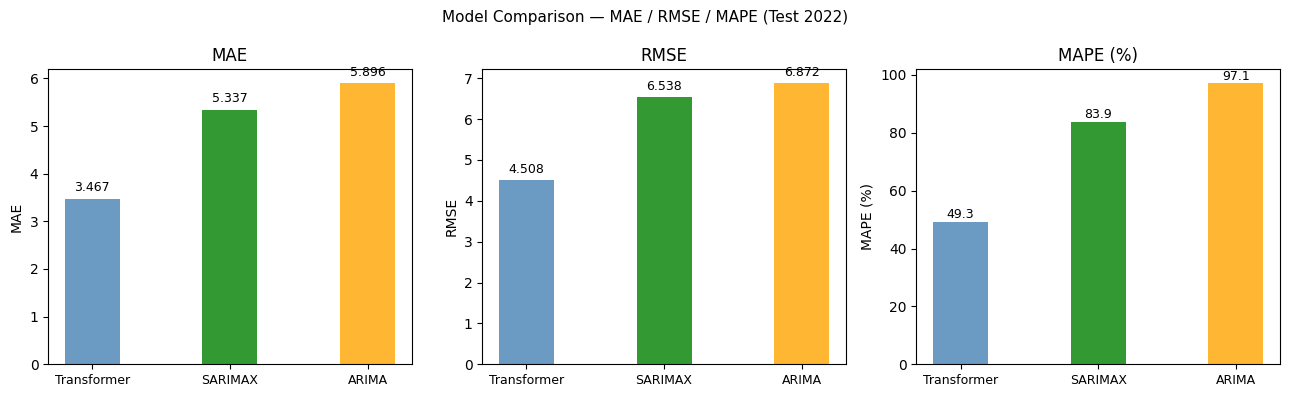

In [17]:
# ── Bar chart: metrics side by side ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ["steelblue", "green", "orange"]
labels = ["Transformer", "SARIMAX", "ARIMA"]

for ax, metric in zip(axes, ["MAE", "RMSE", "MAPE (%)"]):
    vals = metrics_df[metric].tolist()
    bars = ax.bar(labels, vals, color=colors, alpha=0.8, width=0.4)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                str(v), ha="center", va="bottom", fontsize=9)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=9)

plt.suptitle("Model Comparison — MAE / RMSE / MAPE (Test 2022)", fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig_model_comparison_bar.png", dpi=150)
plt.show()